In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings()

In [ ]:
sm_adata = ad.read_h5ad("../data/mouse_E16.5_E1S1_smooth.h5ad")

In [3]:
print(sm_adata.shape)

(218394, 20203)


In [4]:
pearsonR_mat, _ = smoothie.compute_correlation_matrix(sm_adata.X)

compute_correlation_matrix running...
Total runtime for compute_correlation_matrix: 864.63 seconds.



Running network clustering with parameters:
PCC hard cutoff: 0.3, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.4, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.5, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.6, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.7, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.8, clustering soft power: 1, 3, 5, 7, 9, 


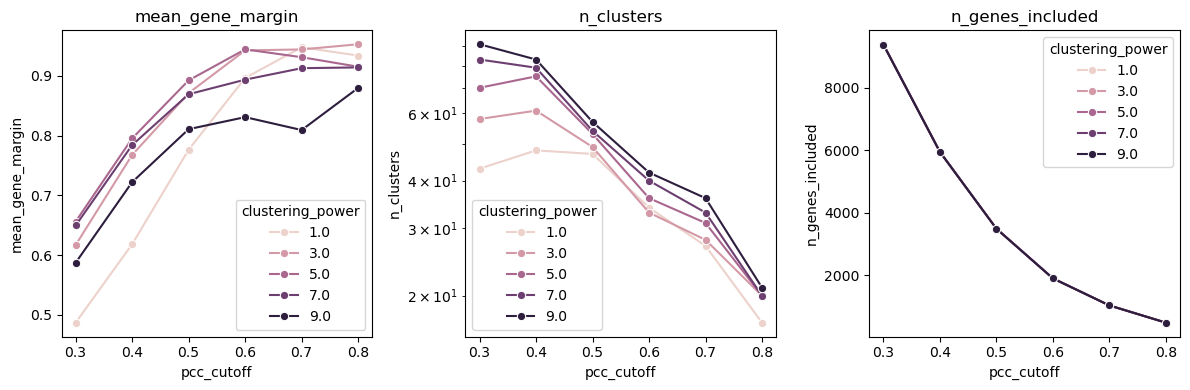

In [5]:
smoothie.select_clustering_params(
    gene_names=sm_adata.var_names,
    pearsonR_mat=pearsonR_mat,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [6]:
edge_list, node_label_df = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=2,
    output_folder='./out'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df = node_label_df.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df

,name,module_label,degree,weighted_degree,rescaled_weighted_degree,clustering_coeff,margin_score
0,Tuba1a,1,1478,812.904382,147.721488,0.247334,0.787678
1,Rtn1,1,1372,755.943485,136.671721,0.270682,0.778707
2,Lrba,1,1614,863.133539,130.268885,0.216896,0.607474
3,Tmsb10,1,1579,845.484801,128.663840,0.225472,0.619024
4,Basp1,1,1432,775.636783,126.642332,0.259535,0.797139
...,...,...,...,...,...,...,...
5940,Hacl1,239,1,0.500989,0.028330,0.000000,1.000000
5941,Uqcr10,240,127,57.204736,1.576539,0.844144,0.977641
5942,4930481A15Rik,240,93,40.935919,0.939691,0.904862,0.986124
5943,Gm28374,241,1,0.436993,0.003801,0.000000,1.000000
